# Figure 5A — Spatial Tricycle theta on tissue

Reproduces panel A of Figure 5: per-spot Tricycle theta projection coloured
onto the cerebellar tissue layout for each of the four treatment groups
(Sal-N, Sal-Hx, LPS-N, LPS-Hx). 8961 Visium spots across 4 sections.

Source pipeline: Kyla Woyshner's `plot_tricycle_mouse_thetaSpatialplots.ipynb`.
Local adaptation: reads from `data/` instead of the lab-server absolute paths;
output renamed to `Fig5A.{pdf,png}`.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Use Arial across all figures (publication consistency)
plt.rcParams['font.family'] = 'Arial'


In [2]:
coords = pd.read_csv('data/coords_mouse.csv', index_col=0)
meta   = pd.read_csv('data/mouse_CB_meta.csv', index_col=0)
tricycle_pos = pd.read_csv('data/tricyclePosition.csv', index_col=0)
meta_folia = meta[meta['folia'] == 'folia']
tricycle_pos_folia = tricycle_pos.loc[meta_folia.index]


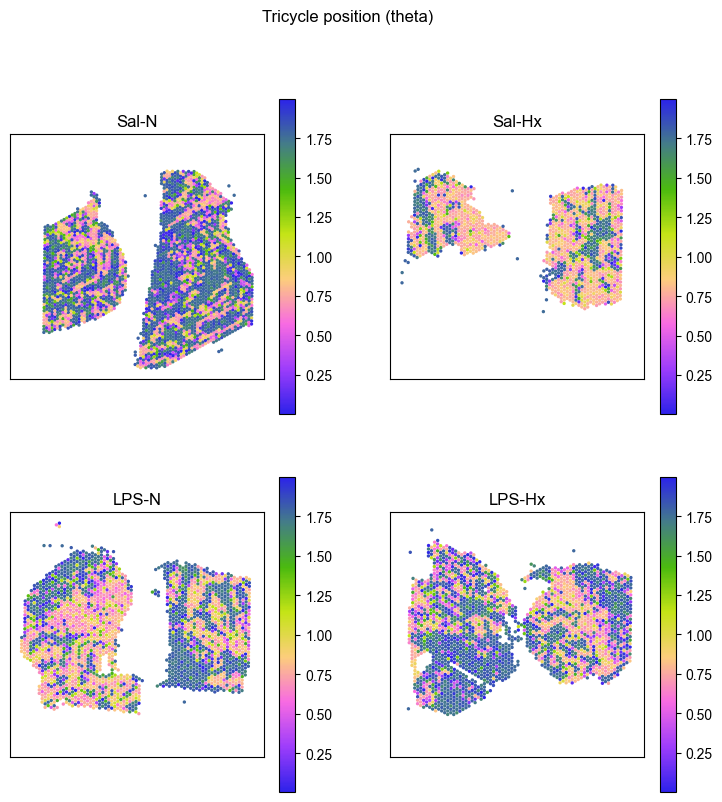

In [3]:
RugPalette_v = ["#2E22EA", "#9E3DFB", "#F86BE2", "#FCCE7B",
                "#C4E416", "#4BBA0F", "#447D87", "#2C24E9"]
rug_cmap = LinearSegmentedColormap.from_list("RugPalette", RugPalette_v)
tricycle_pos['tricyclePosition_theta'] = tricycle_pos['tricyclePosition'] / np.pi

images = ['C', 'MH', 'L', 'DH']
label_map = {'C': 'Sal-N', 'MH': 'Sal-Hx', 'L': 'LPS-N', 'DH': 'LPS-Hx'}

fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True, sharey=True)
fig.suptitle('Tricycle position (theta)')
i = 0
for r in range(axes.shape[0]):
    for c in range(axes.shape[1]):
        im = images[i] + '_'
        patterns_im = tricycle_pos[tricycle_pos.index.str.contains(im)]
        axes[r, c].set(aspect='equal')
        scat = axes[r, c].scatter(
            coords.loc[patterns_im.index, 'imagerow'],
            coords.loc[patterns_im.index, 'imagecol'],
            s=2, c=patterns_im['tricyclePosition_theta'],
            alpha=1, cmap=rug_cmap)
        axes[r, c].set_yticklabels([])
        axes[r, c].set_xticklabels([])
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])
        axes[r, c].set_title(label_map[images[i]])
        fig.colorbar(scat, ax=axes[r, c])
        i += 1

plt.savefig('Fig5A.pdf', bbox_inches='tight')
plt.savefig('Fig5A.png', bbox_inches='tight', dpi=300)
plt.show()
